## 1. Теоретическая часть

**Общая постановка задачи с регуляризацией.**

Обучение модели с регуляризацией записывается как минимизация функционала:

$$
\min_{\theta} \sum_{i=1}^{N} L\left(f(x_i, \theta), y_i\right) + \lambda R(\theta)
$$

где:
- $L(f(x_i,\theta), y_i)$ — функция потерь на объекте $x_i$ (для регрессии обычно квадрат ошибки $L=(f(x_i,\theta)-y_i)^2$);
- $f(x_i,\theta)$ — предсказание модели с параметрами $\theta$;
- $R(\theta)$ — **регуляризующее слагаемое** (штраф за сложность модели);
- $\lambda \geq 0$ — коэффициент регуляризации, задающий баланс между точностью на обучении и простотой модели.

Первое слагаемое отвечает за качество подгонки под данные, второе — ограничивает сложность модели и борется с переобучением. Конкретный вид $R(\theta)$ определяет тип регуляризации: $R(\theta)=\|\theta\|_2^2$ даёт Ridge, $R(\theta)=\|\theta\|_1$ даёт Lasso, их комбинация — ElasticNet.

**Аналитическое решение линейной регрессии.**

Пусть `X` — матрица признаков размера `n x d`, `y` — вектор ответов, а $\theta = w$ — вектор весов. Без регуляризации ($\lambda = 0$) и при квадратичной функции потерь функционал принимает вид:

$$
J(w)=\frac{1}{n}(y-Xw)^T(y-Xw)
$$

Приравниваем градиент к нулю:

$$
\nabla J(w)=-\frac{2}{n}X^T(y-Xw)=0
$$

Отсюда нормальное уравнение:

$$
X^TXw=X^Ty
$$

Если матрица `X^TX` обратима, решение:

$$
\hat w=(X^TX)^{-1}X^Ty
$$

На практике лучше использовать `pinv`, потому что признаки могут быть линейно зависимыми.

**Что меняется при L2-регуляризации (Ridge).**

В общей форме выбираем $R(\theta)=\|w\|_2^2=\sum_i w_i^2$:

$$
J(w)=\frac{1}{n}\|y-Xw\|_2^2+\lambda\|w\|_2^2
$$

Градиент штрафа $\nabla R(w)=2w$ линеен, поэтому аналитическое решение сохраняется:

$$
\hat w=(X^TX+\lambda I)^{-1}X^Ty
$$

Добавка $\lambda I$ делает матрицу обратимой даже при линейно зависимых признаках, а веса равномерно «сжимаются» к нулю (но не становятся ровно нулевыми). Свободный член обычно не регуляризуют.

**Что меняется при L1-регуляризации (Lasso).**

Здесь $R(\theta)=\|w\|_1=\sum_i |w_i|$:

$$
J(w)=\frac{1}{n}\|y-Xw\|_2^2+\lambda\|w\|_1
$$

У модуля нет обычной производной в нуле, поэтому простой аналитической формулы, как у Ridge, нет. Обычно используют координатный спуск, субградиентные методы или проксимальный градиент.

**Почему L1 отбирает признаки.**

L1-регуляризация создаёт разреженные веса: часть коэффициентов становится ровно нулевой. Геометрически это связано с углами L1-шара, а алгоритмически — с оператором soft-thresholding, который зануляет маленькие веса. Если вес признака стал нулём, признак фактически исключён из модели.

**Как линейной моделью обучать нелинейные зависимости.**

Можно заменить исходные признаки `x` на новые признаки $\phi(x)$: степени признаков, произведения признаков, логарифмы, сплайны и другие преобразования. Модель остаётся линейной по весам, но становится нелинейной по исходным переменным:

$$
f(x, w) = w^T \phi(x)
$$

## 2. Предобработка данных. EDA

In [48]:
import math
import warnings
from collections import Counter
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler as SklearnMinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures, StandardScaler as SklearnStandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 21
DATA_PATH = "data/train.json"

df = pd.read_json(DATA_PATH)
print(f"Размер датасета: {df.shape}")
display(df.head())
display(df.info())
display(df.describe())

Размер датасета: (49352, 15)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


None

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


Настроим цветовую палитру КРАЙОЛА

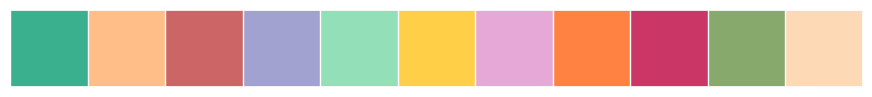

In [49]:
# Названия цветов берём отсюда:
# https://en.wikipedia.org/wiki/List_of_Crayola_crayon_colors
crayon_colors = [
    "Jungle Green",
    "Macaroni and Cheese",  # кремово-оранжевый
    "Fuzzy Wuzzy",  # коричнево-розовый
    "Blue Bell",  # сиренево-синий
    "Sea Green",  # морской зелёный
    "Sunglow",  # солнечно-жёлтый
    "Orchid",  # орхидея
    "Mango Tango",
    "Jazzberry Jam",  # малиновый
    "Asparagus",  # спаржевый зелёный
    "Apricot"
    ]

palette = sns.crayon_palette(crayon_colors)

sns.set_theme(style="darkgrid", palette=palette)
sns.palplot(palette)
plt.show()

Фильтрация выбросов

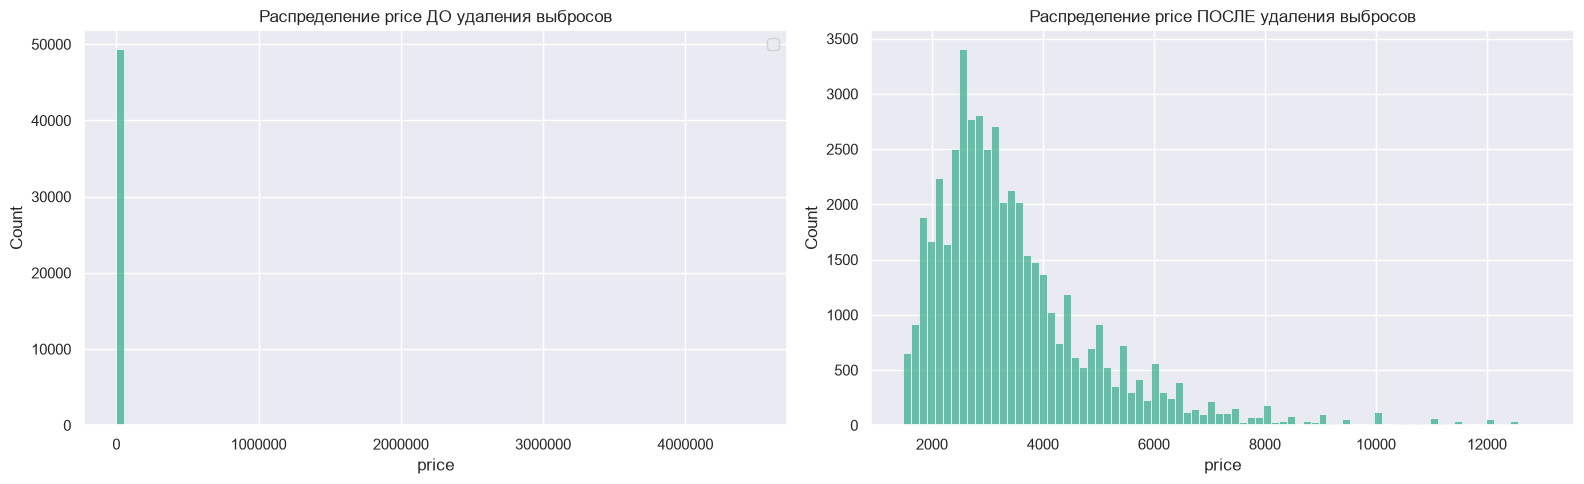

CPU times: total: 672 ms
Wall time: 753 ms


In [50]:
%%time
target_column = "price"

# Вычисляем границы перцентилей
lower_price = df[target_column].quantile(0.01)
upper_price = df[target_column].quantile(0.99)

# Создаём фигуру с двумя осями: 1 ряд, 2 колонки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Левый график: ДО удаления выбросов
sns.histplot(df[target_column], bins=80, ax=ax1)
ax1.set_title("Распределение price ДО удаления выбросов")
ax1.set_xlabel("price")
ax1.ticklabel_format(style='plain', axis='x')
ax1.legend()

# Правый график: ПОСЛЕ удаления выбросов
filtered_data = df[
    df[target_column].between(lower_price, upper_price,
                              # inclusive="both",
                              inclusive="neither",
                              )
].copy()

sns.histplot(filtered_data[target_column], bins=80, ax=ax2)
ax2.set_title("Распределение price ПОСЛЕ удаления выбросов")
ax2.set_xlabel("price")
ax2.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

modeling_df = filtered_data

## 3. Добавление признаков

Подготовка признаков

In [51]:
def clean_feature_name(value):
    """Убираем скобки, кавычки и пробелы из названия признака."""
    return (str(value)
            .replace("[", "")
            .replace("]", "")
            .replace("'", "")
            .replace('"', "")
            .replace(" ", ""))


# Сразу строим Counter через update() — без промежуточных списков
feature_counter_raw = Counter()
feature_counter_clean = Counter()

for feats in modeling_df["features"]:
    if isinstance(feats, list) and len(feats) == 0:
        feature_counter_raw.update([''])
        feature_counter_clean.update([''])
    else:
        raw_vals = [str(f) for f in feats]
        feature_counter_raw.update(raw_vals)
        feature_counter_clean.update(clean_feature_name(v) for v in raw_vals)

print("Популярные признаки")
for name, count in feature_counter_raw.most_common(21):
    print(f"  ('{name}', {count})")

# Итоговые топ-20 (с удалением пробелов) ---
unique_features_count = len(feature_counter_clean)

top_21_clean = feature_counter_clean.most_common(21)
top_20_features = [name for name, _ in top_21_clean if name]

print(f"\nКоличество уникальных значений после очистки: {unique_features_count}")
print("Топ-20 признаков:")
display(top_20_features)

Популярные признаки
  ('Elevator', 25375)
  ('Hardwood Floors', 23146)
  ('Cats Allowed', 23135)
  ('Dogs Allowed', 21652)
  ('Doorman', 20479)
  ('Dishwasher', 20081)
  ('No Fee', 17793)
  ('Laundry in Building', 16082)
  ('Fitness Center', 12989)
  ('Pre-War', 8971)
  ('Laundry in Unit', 8437)
  ('Roof Deck', 6417)
  ('Outdoor Space', 5132)
  ('Dining Room', 4890)
  ('High Speed Internet', 4223)
  ('', 3106)
  ('Balcony', 2898)
  ('Swimming Pool', 2643)
  ('Laundry In Building', 2564)
  ('New Construction', 2504)
  ('Terrace', 2177)

Количество уникальных значений после очистки: 1530
Топ-20 признаков:


['Elevator',
 'HardwoodFloors',
 'CatsAllowed',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace']

Добавим ещё 2 признака и создадим специальную переменную feature_list со всеми именами признаков.

In [52]:
work_df = modeling_df.copy()

# Промежуточный столбец: множество очищенных признаков для каждой строки
work_df["features_clean"] = work_df["features"].apply(
    lambda items: {clean_feature_name(item) for item in items}
    )

# Создаём 20 бинарных признаков
for feature_name in top_20_features:
    work_df[feature_name] = work_df["features_clean"].apply(
        lambda values, fn=feature_name: int(fn in values)
        )

# Удаляем промежуточный столбец
work_df.drop(columns=["features_clean"], inplace=True)

# Формируем итоговый список из 22 признаков
feature_list = ["bathrooms", "bedrooms"] + top_20_features

X = work_df[feature_list].astype(float)
y = work_df[target_column].astype(float)

print(f"Количество признаков: {len(feature_list)}")
print(feature_list)
display(X.head())

Количество признаков: 22
['bathrooms', 'bedrooms', 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


,bathrooms,bedrooms,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,1.5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Разделение на train и test

In [53]:
# Разделение на train и test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    )

print("=" * 38)
print("3: Разделение на тестовую и тренировочную выборки")
print("=" * 38)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

3: Разделение на тестовую и тренировочную выборки
X_train: (36257, 22)
X_test:  (12086, 22)
y_train: (36257,)
y_test:  (12086,)


## МЕТРИКИ

Напишем четыре функции, предназначенные для единообразного расчёта и оформления метрик качества всех моделей проекта.

— Функция rmse(y_true, y_pred)
вычисляет корень из среднеквадратичной ошибки (Root Mean Squared Error).
среднеквадратичная ошибка (MSE) возводит каждую ошибку в квадрат, из-за чего большие отклонения предсказаний от реальных значений получают непропорционально высокий штраф. Извлечение квадратного корня возвращает метрику в исходные единицы измерения целевой переменной

— Функция r2_custom(y_true, y_pred)-
собственная реализация коэффициента детерминации коэффициент детерминации показывает, какую долю дисперсии целевой переменной объясняет модель.
- считает суммы квадратов остатков,
- затем вычисляется базовая изменчивость самих данных
- считает какую долю исходного разброса данных модель НЕ смогла объяснить. Вычитая эту долю из единицы, получаем долю объяснённой дисперсии.
Коэффициент детерминации отвечает на вопрос: «Насколько наша модель лучше, чем просто угадывание среднего значения?»

— Функция collect_metrics(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred)
собирает все три метрики (MAE, RMSE, R²) для одной модели на обучающей и тестовой выборках в единый словарь.

— Функция make_metric_tables(rows)
 преобразует накопленный список словарей с метриками в три отдельные таблицы формата model / train / test.
По мере выполнения проекта в список rows последовательно добавляются результаты всех моделей.



In [54]:
def rmse(y_true, y_pred):
    # Корень из среднеквадратичной ошибки.
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def r2_custom(y_true, y_pred):
    # Собственная реализация коэффициента детерминации R2.
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)  # суммы квадратов остатков
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # базовая изменчивость самих данных
    return float(1 - ss_res / ss_tot)  # доля объяснённой дисперсии


def collect_metrics(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    # Возвращает метрики в удобном для таблиц виде.
    return {
        "model": model_name,
        "MAE_train": mean_absolute_error(y_train_true, y_train_pred),
        "MAE_test": mean_absolute_error(y_test_true, y_test_pred),
        "RMSE_train": rmse(y_train_true, y_train_pred),
        "RMSE_test": rmse(y_test_true, y_test_pred),
        "R2_train": r2_custom(y_train_true, y_train_pred),
        "R2_test": r2_custom(y_test_true, y_test_pred),
        }


def make_metric_tables(rows):
    # Создает отдельные таблицы MAE, RMSE и R2 в формате model/train/test.
    result = pd.DataFrame(rows)
    mae_table = result[["model", "MAE_train", "MAE_test"]].rename(columns={"MAE_train": "train", "MAE_test": "test"})
    rmse_table = result[["model", "RMSE_train", "RMSE_test"]].rename(
        columns={"RMSE_train": "train", "RMSE_test": "test"})
    r2_table = result[["model", "R2_train", "R2_test"]].rename(columns={"R2_train": "train", "R2_test": "test"})
    return result, mae_table, rmse_table, r2_table

In [55]:
# Общий накопитель результатов

rows_all = []   # сюда будем добавлять метрики по мере выполнения заданий


def fit_models(X_tr, X_te, y_tr, y_te, names):
    """Обучает sklearn-модели с параметрами по умолчанию и собирает метрики.
    """
    models = {
        names["linear"]: LinearRegression(),
        names["ridge"]: Ridge(random_state=RANDOM_STATE),
        names["lasso"]: Lasso(max_iter=5000, random_state=RANDOM_STATE),
        names["elastic"]: ElasticNet(max_iter=5000, random_state=RANDOM_STATE),
    }
    rows = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        rows.append(collect_metrics(
            name, y_tr, model.predict(X_tr), y_te, model.predict(X_te)
        ))
    return rows

## 4. Реализация модели Linear regression

In [56]:
class MyLinearModelGD:
    # Линейная модель с batch/mini-batch SGD и опциональной L1/L2-регуляризацией.
    # l1_ratio=0.0 дает Ridge-поведение, l1_ratio=1.0 дает Lasso,
    # промежуточные значения дают ElasticNet.

    def __init__(
        self,
        alpha=0.0,
        l1_ratio=0.0,
        lr=0.05,
        epochs=2500,
        batch_size=None,
        random_state=42,
        fit_intercept=True,
        verbose=False,
        ):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.fit_intercept = fit_intercept
        self.verbose = verbose

    def _prepare_X(self, X):
        X = np.asarray(X, dtype=float)
        if self.fit_intercept:
            return np.c_[np.ones(X.shape[0]), X]
        return X

    def fit(self, X, y):
        X_design = self._prepare_X(X)
        y = np.asarray(y, dtype=float)

        # Масштабируем целевую переменную внутри модели: так GD сходится стабильнее.
        self.y_mean_ = y.mean()
        self.y_std_ = y.std() if y.std() != 0 else 1.0
        y_scaled = (y - self.y_mean_) / self.y_std_

        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X_design.shape
        self.weights_ = np.zeros(n_features)
        batch_size = self.batch_size or n_samples

        for epoch in range(self.epochs):
            indices = rng.permutation(n_samples)
            for start in range(0, n_samples, batch_size):
                batch_idx = indices[start:start + batch_size]
                X_batch = X_design[batch_idx]
                y_batch = y_scaled[batch_idx]

                error = X_batch @ self.weights_ - y_batch
                grad = (X_batch.T @ error) / len(batch_idx)

                # Свободный член не регуляризуем.
                reg_slice = slice(1, None) if self.fit_intercept else slice(None)
                l2_part = (1 - self.l1_ratio) * self.alpha * self.weights_[reg_slice]
                grad[reg_slice] += l2_part
                grad = np.nan_to_num(grad, nan=0.0, posinf=1000.0, neginf=-1000.0)
                grad = np.clip(grad, -1000.0, 1000.0)

                self.weights_ -= self.lr * grad

                # Проксимальный шаг для L1: soft-thresholding.
                if self.alpha > 0 and self.l1_ratio > 0:
                    threshold = self.lr * self.alpha * self.l1_ratio
                    w = self.weights_[reg_slice]
                    self.weights_[reg_slice] = np.sign(w) * np.maximum(np.abs(w) - threshold, 0)

            if self.verbose and epoch % 500 == 0:
                loss = np.mean((X_design @ self.weights_ - y_scaled) ** 2)
                print(f"epoch={epoch}, loss={loss:.6f}")

        return self

    def predict(self, X):
        X_design = self._prepare_X(X)
        pred_scaled = X_design @ self.weights_
        return pred_scaled * self.y_std_ + self.y_mean_


class MyLinearRegressionSGD(MyLinearModelGD):
    def __init__(self, **kwargs):
        super().__init__(alpha=0.0, l1_ratio=0.0, **kwargs)

In [57]:
print("=" * 38)
print("   С Р А В Н Е Н И Е   М Е Т Р И К")
print("=" * 38)

# Обучение кастомной модели (SGD)
my_linreg = MyLinearRegressionSGD(
    lr=0.02, epochs=500, batch_size=512,
    random_state=RANDOM_STATE
    )
my_linreg.fit(X_train, y_train)

# Обучение sklearn модели
sk_linreg = LinearRegression()
sk_linreg.fit(X_train, y_train)

# Сбор метрик через collect_metrics
rows_task4 = []
rows_task4.append(collect_metrics(
    "My Linreg (SGD)",
    y_train, my_linreg.predict(X_train),
    y_test, my_linreg.predict(X_test),
    ))
rows_task4.append(collect_metrics(
    "Linreg default",
    y_train, sk_linreg.predict(X_train),
    y_test, sk_linreg.predict(X_test),
    ))

# Формирование таблиц через make_metric_tables
result_task4, mae_table, rmse_table, r2_table = make_metric_tables(rows_task4)

print("\n>>> result_MAE")
display(mae_table)

print("\n>>> result_RMSE")
display(rmse_table)

print("\n>>> result_R2")
display(r2_table)

   С Р А В Н Е Н И Е   М Е Т Р И К

>>> result_MAE


,model,train,test
0,My Linreg (SGD),707.901222,706.223970
1,Linreg default,709.345472,707.815745



>>> result_RMSE


,model,train,test
0,My Linreg (SGD),1029.494884,1021.160888
1,Linreg default,1029.420649,1021.194843



>>> result_R2


,model,train,test
0,My Linreg (SGD),0.577210,0.588819
1,Linreg default,0.577271,0.588791


## 5. Реализация регуляризованных моделей — Ridge, Lasso, ElasticNet

In [58]:
class MyRidge(MyLinearModelGD):
    def __init__(self, alpha=0.01, **kwargs):
        super().__init__(alpha=alpha, l1_ratio=0.0, **kwargs)


class MyLasso(MyLinearModelGD):
    def __init__(self, alpha=0.0005, **kwargs):
        super().__init__(alpha=alpha, l1_ratio=1.0, **kwargs)


class MyElasticNet(MyLinearModelGD):
    def __init__(self, alpha=0.0005, l1_ratio=0.5, **kwargs):
        super().__init__(alpha=alpha, l1_ratio=l1_ratio, **kwargs)

Детерминированная модель - модель, которая при одинаковых входных данных, одинаковых гиперпараметрах и одинаковом `random_state` всегда дает одинаковый результат. SGD сделан детерминированным через фиксированный генератор случайных чисел `np.random.default_rng(random_state)`.

In [59]:
def fit_predict_custom_and_sklearn(
    X_train_arr, X_test_arr, y_train_arr, y_test_arr, suffix="", custom_lr=0.02, custom_epochs=500, ):
    rows = []

    custom_models = {
        f"Linreg {suffix}": MyLinearRegressionSGD(lr=custom_lr, epochs=custom_epochs, batch_size=512,
                                                        random_state=RANDOM_STATE),
        f"Ridge{suffix}": MyRidge(
            alpha=0.01,
            lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
        f"Lasso{suffix}": MyLasso(
            alpha=0.0005,
            lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
        f"ElasticNet{suffix}": MyElasticNet(
            alpha=0.0005,
            l1_ratio=0.5, lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
        }

    # sklearn_models = {
    #     f"Sklearn LinearRegression{suffix}": LinearRegression(),
    #     f"Sklearn Ridge{suffix}": Ridge(
    #         alpha=0.01,
    #         random_state=RANDOM_STATE),
    #     f"Sklearn Lasso{suffix}": Lasso(
    #         alpha=0.0005,
    #         max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
    #     f"Sklearn ElasticNet{suffix}": ElasticNet(
    #         alpha=0.0005,
    #         l1_ratio=0.5, max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
    #     }

    for name, model in {**custom_models,
                        # **sklearn_models
                        }.items():
        model.fit(X_train_arr, y_train_arr)
        train_pred = model.predict(X_train_arr)
        test_pred = model.predict(X_test_arr)
        rows.append(collect_metrics(name, y_train_arr, train_pred, y_test_arr, test_pred))

    return rows

In [60]:
#Регуляризация

print("=" * 38)
print("    Р Е Г У Л Я Р И З А Ц И Я ")
print("=" * 38)

# --- 1. Запуск обучения всех моделей ---
rows_task5 = fit_predict_custom_and_sklearn(
    X_train, X_test, y_train, y_test, suffix=" default"
    )

# --- 2. Формирование таблиц ---
result_task5, mae_table, rmse_table, r2_table = make_metric_tables(rows_task5)

# print("\n>>> result_MAE")
# display(mae_table)
# print("\n>>> result_RMSE")
# display(rmse_table)
# print("\n>>> result_R2")
# display(r2_table)

# # --- 3. Тепловые карты ---
# print("\n>>> Тепловые карты метрик")
# make_metric_heatmap(rows_task5)


    Р Е Г У Л Я Р И З А Ц И Я 


In [61]:

rows_all += fit_models(X_train, X_test, y_train, y_test, {
    "linear": "Linreg default", "ridge": "Ridre default",
    "lasso": "Lasso default", "elastic": "ElasticNet default",
})

In [62]:
result_final, mae_final, rmse_final, r2_final = make_metric_tables(rows_all)

print(">>> result_MAE")
display(mae_final)
print(">>> result_RMSE")
display(rmse_final)
print(">>> result_R2")
display(r2_final)

>>> result_MAE


,model,train,test
0,Linreg default,709.345472,707.815745
1,Ridre default,709.341919,707.813182
2,Lasso default,708.949530,707.712351
3,ElasticNet default,805.846060,804.406279


>>> result_RMSE


,model,train,test
0,Linreg default,1029.420649,1021.194843
1,Ridre default,1029.420658,1021.196592
2,Lasso default,1029.612841,1021.593688
3,ElasticNet default,1180.903911,1181.427245


>>> result_R2


,model,train,test
0,Linreg default,0.577271,0.588791
1,Ridre default,0.577271,0.588790
2,Lasso default,0.577113,0.588470
3,ElasticNet default,0.443704,0.449624


## 6. Нормализация признаков. Реализация scaler

Класс MyMinMaxScaler
Назначение: нормализация признаков методом MinMaxScaler — приведение каждого признака к диапазону [0, 1].

Формула MinMaxScaler:

$$
x'=\frac{x-x_{min}}{x_{max}-x_{min}}
$$

Формула StandardScaler:

$$
x'=\frac{x-\mu}{\sigma}
$$

Нормализация обязательна или крайне полезна для методов, чувствительных к масштабу: градиентный спуск, линейные модели с регуляризацией, SVM, kNN, PCA, нейронные сети. Она обычно не обязательна для деревьев решений, RandomForest, Gradient Boosting, потому что деревья используют пороговые разбиения и почти не зависят от линейного масштаба признака.

### Где нормализация признаков ОБЯЗАТЕЛЬНА

1. **Методы, основанные на градиентном спуске** (линейная регрессия с SGD,
   нейронные сети). Признаки разного масштаба делают функцию потерь
   «овражной»: градиент движется зигзагами, сходимость замедляется
   или вовсе расходится. Нормализация делает «овраг» округлым.

2. **Метрики расстояний** (k-NN, k-means, SVM с RBF-ядром).
   Если один признак измеряется в тысячах (цена), а другой — в единицах
   (число комнат), то вклад первого в расстояние будет подавляющим,
   и второй признак фактически игнорируется.

3. **Регуляризация (L1/L2)**. Штраф применяется к весам одинаково.
   Признак с малым масштабом получает большой вес, чтобы компенсировать
   масштаб, и регуляризация несправедливо штрафует его сильнее.

4. **Методы, использующие евклидову норму или скалярное произведение**
   (например, PCA). Главные компоненты ищутся по направлению наибольшей
   дисперсии, и признак с большим разбросом искусственно станет «главным».

### Где нормализация НЕ НУЖНА

1. **Деревья решений и ансамбли на их основе** (Random Forest,
   градиентный бустинг). Дерево разбивает данные по порогам:
   важно лишь *упорядочивание* значений, а не их абсолютный масштаб.
   Умножение признака на константу изменит значения порогов,
   но не изменит структуру разбиений.

2. **Наивный Байес для текстов** и другие модели, работающие
   с частотами/вероятностями напрямую.

3. **Когда признаки уже приведены к одному масштабу**
   (например, все бинарные one-hot признаки).

In [63]:
class MyMinMaxScaler:
    # MinMaxScaler: переводит признаки в диапазон [0, 1].

    def fit(self, X):
        """
        Метод принимает обучающую матрицу X, приводит её к массиву numpy и запоминает два статистических параметра по каждому столбцу (axis=0 — вычисления идут вдоль строк, то есть отдельно для каждого признака)
        """
        X = np.asarray(X, dtype=float)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        # защита от деления на ноль
        self.range_ = np.where(self.max_ - self.min_ == 0, 1, self.max_ - self.min_)
        return self

    def transform(self, X):
        """
        непосредственно преобразование данных
        """
        X = np.asarray(X, dtype=float)
        return (X - self.min_) / self.range_

    def fit_transform(self, X):
        """объединение двух шагов: сначала fit, затем transform"""
        return self.fit(X).transform(X)


class MyStandardScaler:
    # StandardScaler: центрирует признаки и делит на стандартное отклонение.
    """
    стандартизация признаков методом StandardScaler — центрирование данных и приведение к единичной дисперсии
    """

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_ = np.where(self.std_ == 0, 1, self.std_)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

Сравним со склёрном:


In [64]:
my_minmax = MyMinMaxScaler()
sk_minmax = SklearnMinMaxScaler()
my_standard = MyStandardScaler()
sk_standard = SklearnStandardScaler()

X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

my_mm_values = my_minmax.fit_transform(X_train_np)
sk_mm_values = sk_minmax.fit_transform(X_train_np)
my_std_values = my_standard.fit_transform(X_train_np)
sk_std_values = sk_standard.fit_transform(X_train_np)

print("Max abs diff для MinMaxScaler:", np.max(np.abs(my_mm_values - sk_mm_values)))
print("Max abs diff для StandardScaler:", np.max(np.abs(my_std_values - sk_std_values)))

Max abs diff для MinMaxScaler: 5.551115123125783e-17
Max abs diff для StandardScaler: 0.0


## 7. Обучение собственных и sklearn-моделей на нормализованных данных

In [65]:
# 7:  Обучение собственных и sklearn-моделей на нормализованных данных

print("=" * 38)
print("7: Обучение на нормализованных данных")
print("=" * 38)

# --- Базовые модели (без нормализации) ---
base_rows = fit_predict_custom_and_sklearn(
    X_train_np,
    X_test_np,
    y_train.to_numpy(dtype=float),
    y_test.to_numpy(dtype=float),
    suffix=" default",
)

all_rows = list(base_rows)

# --- Модели с нормализацией ---

scalers = {
    " MinMaxScaler": MyMinMaxScaler(),
    " StandardScaler": MyStandardScaler(),
}

for suffix, scaler in scalers.items():
    # скейлер обучается ТОЛЬКО на тренировочных
    # данных, а затем применяется и к train, и к test (иначе утечка данных).
    X_train_scaled = scaler.fit_transform(X_train_np)
    X_test_scaled = scaler.transform(X_test_np)

    scaled_rows = fit_predict_custom_and_sklearn(
        X_train_scaled,
        X_test_scaled,
        y_train.to_numpy(dtype=float),
        y_test.to_numpy(dtype=float),
        suffix=suffix,
    )
    all_rows.extend(scaled_rows)

# --- Таблицы метрик (базовые + нормализованные вместе) ---
scaled_result, scaled_mae, scaled_rmse, scaled_r2 = make_metric_tables(all_rows)

print("\n>>> result_MAE")
display(scaled_mae)
print("\n>>> result_RMSE")
display(scaled_rmse)
print("\n>>> result_R2")
display(scaled_r2)

7: Обучение на нормализованных данных

>>> result_MAE


,model,train,test
0,Linreg default,707.901222,706.223970
1,Ridge default,707.347741,705.978475
2,Lasso default,707.560009,706.133711
3,ElasticNet default,707.665032,706.121090
4,Linreg MinMaxScaler,723.850454,723.593394
5,Ridge MinMaxScaler,801.042942,800.350640
6,Lasso MinMaxScaler,724.527922,724.371850
7,ElasticNet MinMaxScaler,726.924890,726.819624
8,Linreg StandardScaler,709.362442,707.830431
9,Ridge StandardScaler,709.226003,707.660985



>>> result_RMSE


,model,train,test
0,Linreg default,1029.494884,1021.160888
1,Ridge default,1030.497849,1022.740572
2,Lasso default,1029.622283,1021.456281
3,ElasticNet default,1029.534462,1021.298612
4,Linreg MinMaxScaler,1050.311018,1044.192843
5,Ridge MinMaxScaler,1175.020786,1173.377943
6,Lasso MinMaxScaler,1052.441833,1046.577419
7,ElasticNet MinMaxScaler,1056.292119,1050.564455
8,Linreg StandardScaler,1029.479890,1021.366017
9,Ridge StandardScaler,1029.570021,1021.525467



>>> result_R2


,model,train,test
0,Linreg default,0.577210,0.588819
1,Ridge default,0.576386,0.587545
2,Lasso default,0.577105,0.588581
3,ElasticNet default,0.577177,0.588708
4,Linreg MinMaxScaler,0.559940,0.570061
5,Ridge MinMaxScaler,0.449233,0.457099
6,Lasso MinMaxScaler,0.558152,0.568095
7,ElasticNet MinMaxScaler,0.554913,0.564798
8,Linreg StandardScaler,0.577222,0.588653
9,Ridge StandardScaler,0.577148,0.588525


## 8. Переобученные модели

Полиномиальные признаки и переобучение

In [66]:
# 8: Переобучение


print("=" * 38)
print("   8: Переобучение")
print("=" * 38)

poly_base_features = ["bathrooms", "bedrooms"]
X_poly_source = work_df[poly_base_features].astype(float)

# Тот же сплит, что и в основном пайплайне (те же random_state и число строк)
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_source, y, test_size=0.25, random_state=RANDOM_STATE
)

# Полиномиальные признаки степени 10
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_train_raw = poly.fit_transform(X_poly_train)
X_poly_test_raw = poly.transform(X_poly_test)
print(f"Полиномиальных признаков: {X_poly_train_raw.shape[1]}")

# Нормализация (важна для численной устойчивости степеней)
poly_scaler = MyStandardScaler()
X_poly_train_scaled = poly_scaler.fit_transform(X_poly_train_raw)
X_poly_test_scaled = poly_scaler.transform(X_poly_test_raw)

# --- Обучаем sklearn-модели
poly_rows = fit_models(
    X_poly_train_scaled, X_poly_test_scaled,
    y_poly_train.to_numpy(dtype=float), y_poly_test.to_numpy(dtype=float),
    names={
        "linear": "Linreg Polynomial", "ridge": "Ridge Polynomial",
        "lasso": "Lasso Polynomial", "elastic": "ElasticNet Polynomial",
    },
)

# --- Добавляем в общий накопитель ---
# Защита от дублирования при повторном запуске ячейки:
# сначала удаляем старые полиномиальные модели, потом добавляем новые
all_rows = all_rows + poly_rows


# --- Смотрим результаты полиномиальных моделей отдельно ---
poly_result, poly_mae, poly_rmse, poly_r2 = make_metric_tables(poly_rows)




# print("\n>>> result_MAE (полиномиальные модели)")
# display(poly_mae.sort_values("test", ascending=False).reset_index(drop=True))
#
# print("\n>>> result_RMSE (полиномиальные модели)")
# display(poly_rmse.sort_values("test", ascending=False).reset_index(drop=True))
#
# print("\n>>> result_R2 (полиномиальные модели)")
# display(poly_r2.sort_values("test", ascending=False).reset_index(drop=True))
#
# --- Общая таблица со всеми моделями ---
result_all, mae_all, rmse_all, r2_all = make_metric_tables(all_rows)

print(f"\nВсего моделей в общей таблице: {len(result_all)}")

print("\n>>> result_MAE (все модели)")
display(mae_all)

print("\n>>> result_RMSE (все модели)")
display(rmse_all)

print("\n>>> result_R2 (все модели)")
display(r2_all)

# display(rows_all)

   8: Переобучение
Полиномиальных признаков: 65

Всего моделей в общей таблице: 16

>>> result_MAE (все модели)


,model,train,test
0,Linreg default,707.901222,706.223970
1,Ridge default,707.347741,705.978475
2,Lasso default,707.560009,706.133711
3,ElasticNet default,707.665032,706.121090
4,Linreg MinMaxScaler,723.850454,723.593394
5,Ridge MinMaxScaler,801.042942,800.350640
6,Lasso MinMaxScaler,724.527922,724.371850
7,ElasticNet MinMaxScaler,726.924890,726.819624
8,Linreg StandardScaler,709.362442,707.830431
9,Ridge StandardScaler,709.226003,707.660985



>>> result_RMSE (все модели)


,model,train,test
0,Linreg default,1029.494884,1021.160888
1,Ridge default,1030.497849,1022.740572
2,Lasso default,1029.622283,1021.456281
3,ElasticNet default,1029.534462,1021.298612
4,Linreg MinMaxScaler,1050.311018,1044.192843
5,Ridge MinMaxScaler,1175.020786,1173.377943
6,Lasso MinMaxScaler,1052.441833,1046.577419
7,ElasticNet MinMaxScaler,1056.292119,1050.564455
8,Linreg StandardScaler,1029.479890,1021.366017
9,Ridge StandardScaler,1029.570021,1021.525467



>>> result_R2 (все модели)


,model,train,test
0,Linreg default,0.577210,0.588819
1,Ridge default,0.576386,0.587545
2,Lasso default,0.577105,0.588581
3,ElasticNet default,0.577177,0.588708
4,Linreg MinMaxScaler,0.559940,0.570061
5,Ridge MinMaxScaler,0.449233,0.457099
6,Lasso MinMaxScaler,0.558152,0.568095
7,ElasticNet MinMaxScaler,0.554913,0.564798
8,Linreg StandardScaler,0.577222,0.588653
9,Ridge StandardScaler,0.577148,0.588525


## 9. Наивные модели

In [67]:
# ========================================
# 9: Наивные модели
# ========================================
print("=" * 38)
print("9: Наивные модели")
print("=" * 38)

train_mean = y_train.mean()
train_median = y_train.median()

naive_rows = []
for name, constant_value in {
    "Naive mean": train_mean,
    "Naive median": train_median,
}.items():
    train_pred = np.full_like(
        y_train.to_numpy(dtype=float),
        fill_value=constant_value,
        dtype=float,
    )
    test_pred = np.full_like(
        y_test.to_numpy(dtype=float),
        fill_value=constant_value,
        dtype=float,
    )
    naive_rows.append(
        collect_metrics(name, y_train, train_pred, y_test, test_pred)
    )

# --- Объединяем с предыдущими результатами (Task 7) ---
# rows_task7 — список словарей, собранный ранее в задании 7.
# Если он ещё не определён в этом скоупе, создаём пустой список:
if 'rows_task7' not in globals():
    rows_task7 = []

all_rows = all_rows + naive_rows # todo

# # --- Пересобираем все таблицы целиком ---
# result_all, mae_table_all, rmse_table_all, r2_table_all = make_metric_tables(rows_all)
#
# print("\n>>> result_MAE (с наивными моделями)")
# display(mae_table_all)
#
# print("\n>>> result_RMSE (с наивными моделями)")
# display(rmse_table_all)
#
# print("\n>>> result_R2 (с наивными моделями)")
# display(r2_table_all)
result_final, mae_final, rmse_final, r2_final = make_metric_tables(all_rows)

print(">>> result_MAE")
display(mae_final)
print(">>> result_RMSE")
display(rmse_final)
print(">>> result_R2")
display(r2_final)



9: Наивные модели
>>> result_MAE


,model,train,test
0,Linreg default,707.901222,706.223970
1,Ridge default,707.347741,705.978475
2,Lasso default,707.560009,706.133711
3,ElasticNet default,707.665032,706.121090
4,Linreg MinMaxScaler,723.850454,723.593394
5,Ridge MinMaxScaler,801.042942,800.350640
6,Lasso MinMaxScaler,724.527922,724.371850
7,ElasticNet MinMaxScaler,726.924890,726.819624
8,Linreg StandardScaler,709.362442,707.830431
9,Ridge StandardScaler,709.226003,707.660985


>>> result_RMSE


,model,train,test
0,Linreg default,1029.494884,1021.160888
1,Ridge default,1030.497849,1022.740572
2,Lasso default,1029.622283,1021.456281
3,ElasticNet default,1029.534462,1021.298612
4,Linreg MinMaxScaler,1050.311018,1044.192843
5,Ridge MinMaxScaler,1175.020786,1173.377943
6,Lasso MinMaxScaler,1052.441833,1046.577419
7,ElasticNet MinMaxScaler,1056.292119,1050.564455
8,Linreg StandardScaler,1029.479890,1021.366017
9,Ridge StandardScaler,1029.570021,1021.525467


>>> result_R2


,model,train,test
0,Linreg default,0.577210,0.588819
1,Ridge default,0.576386,0.587545
2,Lasso default,0.577105,0.588581
3,ElasticNet default,0.577177,0.588708
4,Linreg MinMaxScaler,0.559940,0.570061
5,Ridge MinMaxScaler,0.449233,0.457099
6,Lasso MinMaxScaler,0.558152,0.568095
7,ElasticNet MinMaxScaler,0.554913,0.564798
8,Linreg StandardScaler,0.577222,0.588653
9,Ridge StandardScaler,0.577148,0.588525


## 10. Финальное сравнение

In [68]:
# ========================================
# Задание 10: финальные таблицы
# ========================================
result_final, mae_final, rmse_final, r2_final = make_metric_tables(all_rows)

print(">>> result_MAE")
display(mae_final)
print(">>> result_RMSE")
display(rmse_final)
print(">>> result_R2")
display(r2_final)

>>> result_MAE


,model,train,test
0,Linreg default,707.901222,706.223970
1,Ridge default,707.347741,705.978475
2,Lasso default,707.560009,706.133711
3,ElasticNet default,707.665032,706.121090
4,Linreg MinMaxScaler,723.850454,723.593394
5,Ridge MinMaxScaler,801.042942,800.350640
6,Lasso MinMaxScaler,724.527922,724.371850
7,ElasticNet MinMaxScaler,726.924890,726.819624
8,Linreg StandardScaler,709.362442,707.830431
9,Ridge StandardScaler,709.226003,707.660985


>>> result_RMSE


,model,train,test
0,Linreg default,1029.494884,1021.160888
1,Ridge default,1030.497849,1022.740572
2,Lasso default,1029.622283,1021.456281
3,ElasticNet default,1029.534462,1021.298612
4,Linreg MinMaxScaler,1050.311018,1044.192843
5,Ridge MinMaxScaler,1175.020786,1173.377943
6,Lasso MinMaxScaler,1052.441833,1046.577419
7,ElasticNet MinMaxScaler,1056.292119,1050.564455
8,Linreg StandardScaler,1029.479890,1021.366017
9,Ridge StandardScaler,1029.570021,1021.525467


>>> result_R2


,model,train,test
0,Linreg default,0.577210,0.588819
1,Ridge default,0.576386,0.587545
2,Lasso default,0.577105,0.588581
3,ElasticNet default,0.577177,0.588708
4,Linreg MinMaxScaler,0.559940,0.570061
5,Ridge MinMaxScaler,0.449233,0.457099
6,Lasso MinMaxScaler,0.558152,0.568095
7,ElasticNet MinMaxScaler,0.554913,0.564798
8,Linreg StandardScaler,0.577222,0.588653
9,Ridge StandardScaler,0.577148,0.588525


### 10.b. Какая модель лучшая?

Основываясь на метриках тестовой выборки, лучшей моделью является **линейная регрессия без нормализации (дефолт)**.

Она демонстрирует наилучшие значения сразу по двум ключевым метрикам:
- **Коэффициент детерминации на тесте:** R² ≈ 0.5888 — самый высокий среди всех моделей
- **Среднеквадратичная ошибка на тесте:** RMSE ≈ 1021.16 — самая низкая среди всех моделей

Модель **ЭластикНет дефолт** показывает практически идентичные результаты (МАЕ ≈ 706.12, RMSE ≈ 1021.30, R² ≈ 0.5887) и является достойной альтернативой.

Важно отметить, что все модели без нормализации (дефолт) показывают очень близкие результаты. Это ожидаемо, поскольку линейные модели инвариантны к масштабу признаков — нормализация не влияет на их качество. В то же время модели со скейлерами (особенно `Ridge MinMaxScaler` с R² ≈ 0.457) и полиномиальные модели заметно хуже, что свидетельствует об их меньшей эффективности для данной задачи.

### 10.c. Какая модель самая стабильная?

Самой стабильной моделью является **Ридж без нормализации (дефолт)**.

Стабильность модели оценивается по минимальной разнице метрик между тренировочной и тестовой выборками. Чем меньше разрыв, тем меньше модель переобучается и тем надёжнее её прогнозы на новых данных.

Для Ридж дефолт эта разница минимальна по всем трём метрикам.

Все модели дефолт демонстрируют высокую стабильность, что логично для линейных моделей на таких данных. Однако **Ридж** за счёт регуляризации с нормой 2 дополнительно сдерживает рост весов, что делает его прогнозы чуть более предсказуемыми.

В противоположность этому, модели со скейлерами (особенно `Ridge MinMaxScaler`) и полиномиальные модели показывают больший разрыв между трейном и тестом, что указывает на их склонность к переобучению.

In [69]:
print("=" * 38, datetime.now(), 'jacquieb', sep="\n")

2026-08-25 21:56:46.384745
jacquieb
